# IAT 特徵洩漏驗證：只用 IAT 一個特徵訓練模型

CICIoT2023 的 `IAT` 在論文中定義為「與前一個封包的時間差」，但資料集裡 95.6% 的值集中在約 8.3e7，呈現三峰分佈，
換算成秒是 2.6 年，物理上不可能是封包間隔。

**驗證方式**：只用 `IAT` 這一個特徵訓練決策樹。如果單一特徵就能把攻擊類別分得很好，代表這個欄位帶有與網路行為無關的標籤資訊（洩漏）。

**流程**
1. 載入資料並對應到模型使用的 8 大類
2. 觀察 IAT 的分佈與各類別的關係
3. 只用 IAT 訓練決策樹（深度 1～3），呈現正確率
4. 學習過程：深度曲線、學習曲線
5. 混淆矩陣與分類報告
6. 樹結構：模型實際使用的 IAT 門檻
7. 在同一份資料切分下，與 46 特徵隨機森林比較

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, classification_report)

RANDOM_STATE = 0

# 往上尋找含有 data/*.csv 的專案根目錄（notebook 放在 document/ 底下也能執行）
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if list((p / "data").glob("*.csv")))
DATA_FILES = sorted((ROOT / "data").glob("*.csv"))
print(f"專案根目錄: {ROOT}")
print(f"資料檔數量: {len(DATA_FILES)}")

# 中文字型：依序找系統上可用的 CJK 字型
_cjk = [f.name for f in font_manager.fontManager.ttflist
        if f.name in ("Noto Sans CJK TC", "Noto Sans CJK JP", "Microsoft JhengHei",
                      "PingFang TC", "WenQuanYi Zen Hei", "Droid Sans Fallback", "SimHei")]
# 英數字用 DejaVu Sans，中文逐字 fallback 到 CJK 字型（CJK 字型多半沒有英數字，不能放第一個）
plt.rcParams["font.family"] = ["DejaVu Sans"] + _cjk[:1]
plt.rcParams["mathtext.fontset"] = "dejavusans"      # 對數刻度的 10² 這類標籤
plt.rcParams["axes.unicode_minus"] = False
print("圖表字型:", plt.rcParams["font.family"])
if not _cjk:
    print("警告：找不到中文字型，圖中的中文會顯示為方塊")

專案根目錄: /home/pccu1/bominwang/XaIds_Min_260313
資料檔數量: 10
圖表字型: ['DejaVu Sans', 'Droid Sans Fallback']


## 1. 載入資料並對應到 8 大類

類別對應與模型的 `label_encoder` 相同：Benign、Brute Force、DDoS、DoS、Mirai、Recon、Spoofing、Web-based。
這一步只讀 `IAT` 與 `label` 兩欄。

In [2]:
LABEL_MAP = {
    "BenignTraffic": "Benign",
    "DictionaryBruteForce": "Brute Force",
    "DNS_Spoofing": "Spoofing",
    "MITM-ArpSpoofing": "Spoofing",
    "VulnerabilityScan": "Recon",
}
WEB_ATTACKS = {"Backdoor_Malware", "BrowserHijacking", "CommandInjection",
               "SqlInjection", "Uploading_Attack", "XSS"}


def to_group(label):
    if label in LABEL_MAP:
        return LABEL_MAP[label]
    if label in WEB_ATTACKS:
        return "Web-based"
    return label.split("-")[0]          # DDoS-xxx / DoS-xxx / Mirai-xxx / Recon-xxx


t0 = time.time()
df = pd.concat([pd.read_csv(f, usecols=["IAT", "label"]) for f in DATA_FILES], ignore_index=True)
df["y"] = df["label"].map(to_group)
CLASSES = sorted(df["y"].unique())

print(f"總列數: {len(df):,}（讀取 {time.time() - t0:.1f}s）")
counts = df["y"].value_counts()
print(pd.DataFrame({"列數": counts, "比例": (counts / len(df)).map("{:.2%}".format)}).to_string())

總列數: 2,366,956（讀取 3.8s）
                  列數      比例
y                           
DDoS         1723607  72.82%
DoS           409683  17.31%
Mirai         133220   5.63%
Benign         55859   2.36%
Spoofing       24760   1.05%
Recon          17985   0.76%
Web-based       1186   0.05%
Brute Force      656   0.03%


## 2. IAT 的分佈

把 IAT 除以最大值後分成 20 格：幾乎所有值都落在 0、0.5、1 三個位置，中間是空的，不像連續的時間量測。
右圖是各類別落在三個峰的比例。

IAT 最大值: 1.67639e+08  → 若單位為秒 = 5.32 年
中峰中位數: 8.31245e+07  → 2.64 年
低峰（真實封包間隔）範圍: 0 ~ 36 秒

各類別落在三個峰的比例 (%)
col_0        低峰 ≈0  中峰 ≈max/2  高峰 ≈max   其他
y                                          
Benign        49.9        0.0     50.1  0.0
Brute Force   50.5        0.0     49.5  0.0
DDoS           0.0      100.0      0.0  0.0
DoS            0.0      100.0      0.0  0.0
Mirai          0.1       99.7      0.0  0.2
Recon         44.7       10.4     44.8  0.0
Spoofing      50.0        0.0     50.0  0.0
Web-based     51.4        0.0     48.6  0.0


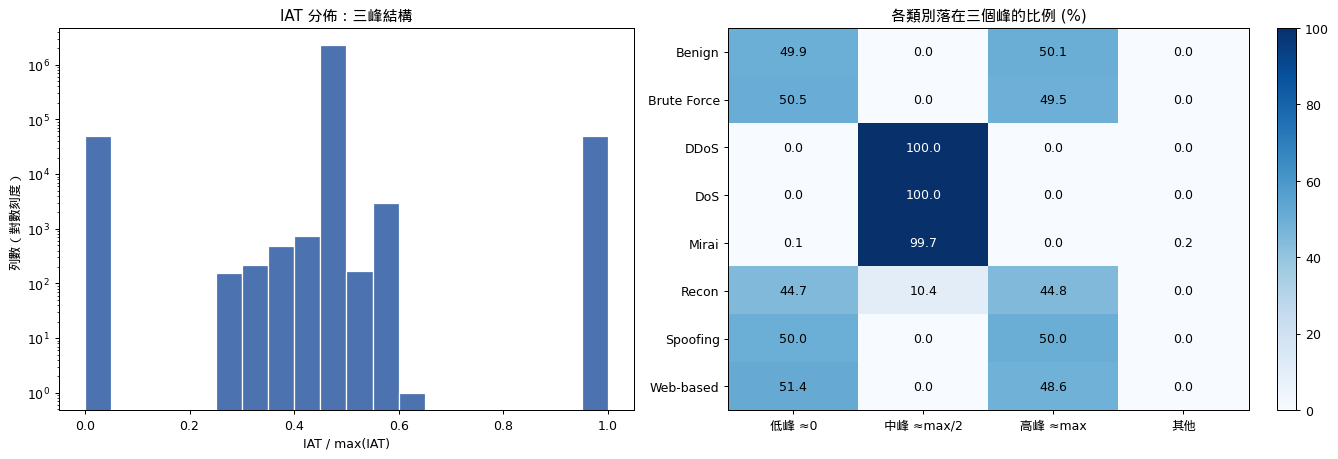

In [3]:
IAT_MAX = df["IAT"].max()
ratio = df["IAT"] / IAT_MAX
mode = np.select([ratio < 0.05, (ratio > 0.4) & (ratio < 0.6), ratio > 0.9],
                 ["低峰 ≈0", "中峰 ≈max/2", "高峰 ≈max"], "其他")
MODES = ["低峰 ≈0", "中峰 ≈max/2", "高峰 ≈max", "其他"]

print(f"IAT 最大值: {IAT_MAX:.6g}  → 若單位為秒 = {IAT_MAX / 86400 / 365:.2f} 年")
print(f"中峰中位數: {df.loc[mode == '中峰 ≈max/2', 'IAT'].median():.6g}"
      f"  → {df.loc[mode == '中峰 ≈max/2', 'IAT'].median() / 86400 / 365:.2f} 年")
print(f"低峰（真實封包間隔）範圍: {df.loc[mode == '低峰 ≈0', 'IAT'].min():.3g} ~ "
      f"{df.loc[mode == '低峰 ≈0', 'IAT'].max():.3g} 秒")

crosstab = pd.crosstab(df["y"], mode, normalize="index").reindex(columns=MODES, fill_value=0) * 100
print("\n各類別落在三個峰的比例 (%)")
print(crosstab.round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

axes[0].hist(ratio, bins=20, range=(0, 1), color="#4C72B0", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_xlabel("IAT / max(IAT)")
axes[0].set_ylabel("列數（對數刻度）")
axes[0].set_title("IAT 分佈：三峰結構")

im = axes[1].imshow(crosstab.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
axes[1].set_xticks(range(len(MODES)), MODES)
axes[1].set_yticks(range(len(crosstab.index)), crosstab.index)
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        v = crosstab.values[i, j]
        axes[1].text(j, i, f"{v:.1f}", ha="center", va="center",
                     color="white" if v > 60 else "black", fontsize=10)
axes[1].set_title("各類別落在三個峰的比例 (%)")
fig.colorbar(im, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()

## 3. 只用 IAT 訓練決策樹（深度 1～3）

- 資料切分：75% 訓練 / 25% 測試，依類別分層抽樣
- 特徵：**只有 `IAT` 一欄**
- 對照組：永遠猜最多數類別（DDoS）的基準模型

因為 DDoS 佔 72.8%，accuracy 會被多數類別撐高，所以同時呈現 **balanced accuracy** 與 **macro-F1**（各類別權重相同）。

訓練集: 1,775,217 列   測試集: 591,739 列
             訓練 accuracy  測試 accuracy  測試 balanced acc  測試 macro-F1   訓練秒數
模型                                                                        
基準：永遠猜多數類         0.7282       0.7282           0.1250       0.1053 2.6047
只用 IAT，深度 1       0.9004       0.9005           0.2498       0.2361 5.3722
只用 IAT，深度 2       0.9672       0.9673           0.4364       0.4189 5.6348
只用 IAT，深度 3       0.9793       0.9792           0.4981       0.4623 5.9341


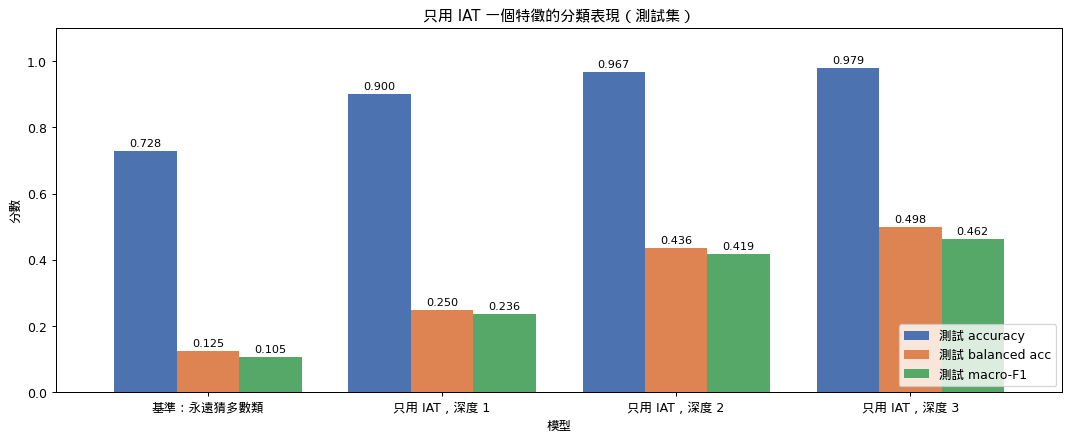

In [4]:
X = df[["IAT"]]
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
print(f"訓練集: {len(X_train):,} 列   測試集: {len(X_test):,} 列")


def evaluate(name, model, Xtr, Xte, ytr, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    fit_s = time.time() - t0
    pred_tr, pred_te = model.predict(Xtr), model.predict(Xte)
    return {
        "模型": name,
        "訓練 accuracy": accuracy_score(ytr, pred_tr),
        "測試 accuracy": accuracy_score(yte, pred_te),
        "測試 balanced acc": balanced_accuracy_score(yte, pred_te),
        "測試 macro-F1": f1_score(yte, pred_te, average="macro", zero_division=0),
        "訓練秒數": fit_s,
    }


rows = [evaluate("基準：永遠猜多數類", DummyClassifier(strategy="most_frequent"),
                 X_train, X_test, y_train, y_test)]
iat_trees = {}
for depth in (1, 2, 3):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    rows.append(evaluate(f"只用 IAT，深度 {depth}", tree, X_train, X_test, y_train, y_test))
    iat_trees[depth] = tree

result_iat = pd.DataFrame(rows).set_index("模型")
print(result_iat.to_string(float_format=lambda v: f"{v:.4f}"))

metrics = ["測試 accuracy", "測試 balanced acc", "測試 macro-F1"]
ax = result_iat[metrics].plot.bar(figsize=(12, 5), rot=0, width=0.8,
                                  color=["#4C72B0", "#DD8452", "#55A868"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)
ax.set_ylim(0, 1.1)
ax.set_ylabel("分數")
ax.set_title("只用 IAT 一個特徵的分類表現（測試集）")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. 學習過程

決策樹沒有 epoch，因此用兩種曲線呈現「模型怎麼學到這個結果」：

- **深度曲線**：樹的深度（模型容量）從 1 增加到 12，訓練與測試分數的變化
- **學習曲線**：固定深度 3，訓練資料量從 0.1% 增加到 100%，5-fold 交叉驗證的訓練與驗證 accuracy

如果 IAT 只是雜訊，模型需要大量資料和深樹才能擬合；如果它直接洩漏標籤，極少的資料和很淺的樹就會飽和。

    訓練 accuracy  測試 accuracy  測試 macro-F1  葉節點數
深度                                             
1        0.9004       0.9005       0.2361     2
2        0.9672       0.9673       0.4189     4
3        0.9793       0.9792       0.4623     7
4        0.9860       0.9858       0.5786    11
5        0.9879       0.9878       0.6208    16
6        0.9903       0.9902       0.7323    24
7        0.9910       0.9910       0.8195    38
8        0.9912       0.9911       0.8193    57
9        0.9912       0.9911       0.8191    92
10       0.9913       0.9911       0.8197   151
11       0.9914       0.9911       0.8195   237
12       0.9914       0.9911       0.8185   361


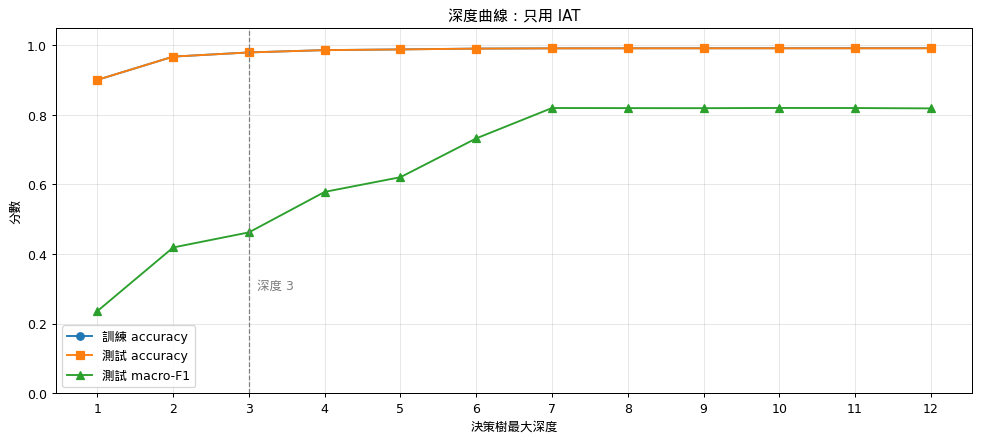

In [5]:
depths = list(range(1, 13))
depth_rows = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    p_tr, p_te = m.predict(X_train), m.predict(X_test)
    depth_rows.append({
        "深度": d,
        "訓練 accuracy": accuracy_score(y_train, p_tr),
        "測試 accuracy": accuracy_score(y_test, p_te),
        "測試 macro-F1": f1_score(y_test, p_te, average="macro", zero_division=0),
        "葉節點數": m.get_n_leaves(),
    })
depth_curve = pd.DataFrame(depth_rows).set_index("深度")
print(depth_curve.to_string(float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, depth_curve["訓練 accuracy"], "o-", label="訓練 accuracy")
ax.plot(depths, depth_curve["測試 accuracy"], "s-", label="測試 accuracy")
ax.plot(depths, depth_curve["測試 macro-F1"], "^-", label="測試 macro-F1")
ax.axvline(3, color="gray", ls="--", lw=1)
ax.text(3.1, 0.3, "深度 3", color="gray")
ax.set_xticks(depths)
ax.set_xlabel("決策樹最大深度")
ax.set_ylabel("分數")
ax.set_ylim(0, 1.05)
ax.set_title("深度曲線：只用 IAT")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

學習曲線計算時間: 42.1s
         訓練 acc 平均  驗證 acc 平均  驗證 acc 標準差
訓練列數                                     
1420        0.9839     0.9790      0.0002
4260        0.9808     0.9787      0.0008
14201       0.9803     0.9793      0.0001
42605       0.9799     0.9794      0.0001
142017      0.9793     0.9794      0.0002
426051      0.9794     0.9793      0.0000
852103      0.9794     0.9793      0.0000
1420173     0.9793     0.9793      0.0000


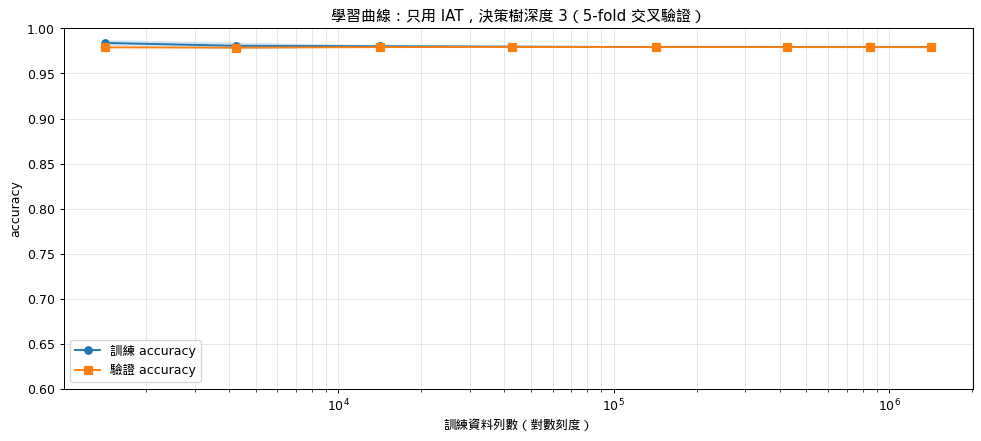

In [6]:
train_sizes = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 0.6, 1.0]
t0 = time.time()
sizes, train_scores, val_scores = learning_curve(
    DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    X_train, y_train,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy",
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
print(f"學習曲線計算時間: {time.time() - t0:.1f}s")

lc = pd.DataFrame({
    "訓練列數": sizes,
    "訓練 acc 平均": train_scores.mean(axis=1),
    "驗證 acc 平均": val_scores.mean(axis=1),
    "驗證 acc 標準差": val_scores.std(axis=1),
}).set_index("訓練列數")
print(lc.to_string(float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(11, 5))
for scores, label, marker in [(train_scores, "訓練 accuracy", "o-"), (val_scores, "驗證 accuracy", "s-")]:
    mean, std = scores.mean(axis=1), scores.std(axis=1)
    ax.plot(sizes, mean, marker, label=label)
    ax.fill_between(sizes, mean - std, mean + std, alpha=0.2)
ax.set_xscale("log")
ax.set_xlabel("訓練資料列數（對數刻度）")
ax.set_ylabel("accuracy")
ax.set_ylim(0.6, 1.0)
ax.set_title("學習曲線：只用 IAT，決策樹深度 3（5-fold 交叉驗證）")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

## 5. 混淆矩陣與分類報告（深度 3）

混淆矩陣以「真實類別」為列做正規化，每一列加總為 100%，對角線即為該類別的召回率。

              precision    recall  f1-score   support

      Benign     0.5462    1.0000    0.7065     13965
 Brute Force     0.0000    0.0000    0.0000       164
        DDoS     0.9984    0.9987    0.9986    430902
         DoS     1.0000    0.9982    0.9991    102421
       Mirai     1.0000    0.9879    0.9939     33305
       Recon     0.0000    0.0000    0.0000      4496
    Spoofing     0.0000    0.0000    0.0000      6190
   Web-based     0.0000    0.0000    0.0000       296

    accuracy                         0.9792    591739
   macro avg     0.4431    0.4981    0.4623    591739
weighted avg     0.9693    0.9792    0.9727    591739



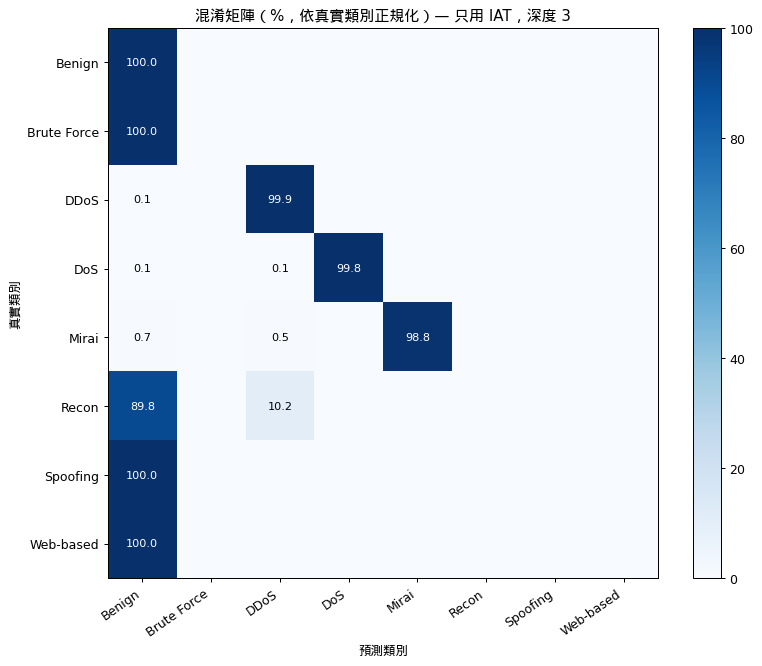

In [7]:
best = iat_trees[3]
pred = best.predict(X_test)
cm = confusion_matrix(y_test, pred, labels=CLASSES, normalize="true") * 100

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(CLASSES)), CLASSES, rotation=35, ha="right")
ax.set_yticks(range(len(CLASSES)), CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if cm[i, j] >= 0.05:
            ax.text(j, i, f"{cm[i, j]:.1f}", ha="center", va="center",
                    color="white" if cm[i, j] > 60 else "black", fontsize=9)
ax.set_xlabel("預測類別")
ax.set_ylabel("真實類別")
ax.set_title("混淆矩陣（%，依真實類別正規化）— 只用 IAT，深度 3")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred, labels=CLASSES, digits=4, zero_division=0))

## 6. 樹結構：模型實際使用的 IAT 門檻

把門檻值換算成「IAT / max(IAT)」，可以看出模型切的位置正好落在三個峰之間。

分裂節點（IAT 門檻）：
  節點  0: IAT <= 8.30333e+07   （= 0.4953 × max）  樣本數 1,775,217
  節點  1: IAT <= 8.284e+07   （= 0.4942 × max）  樣本數 345,603
  節點  2: IAT <= 2.12676e+07   （= 0.1269 × max）  樣本數 38,889
  節點  6: IAT <= 8.35343e+07   （= 0.4983 × max）  樣本數 1,429,614
  節點  7: IAT <= 8.31993e+07   （= 0.4963 × max）  樣本數 1,291,533
  節點 10: IAT <= 9.1665e+07   （= 0.5468 × max）  樣本數 138,081


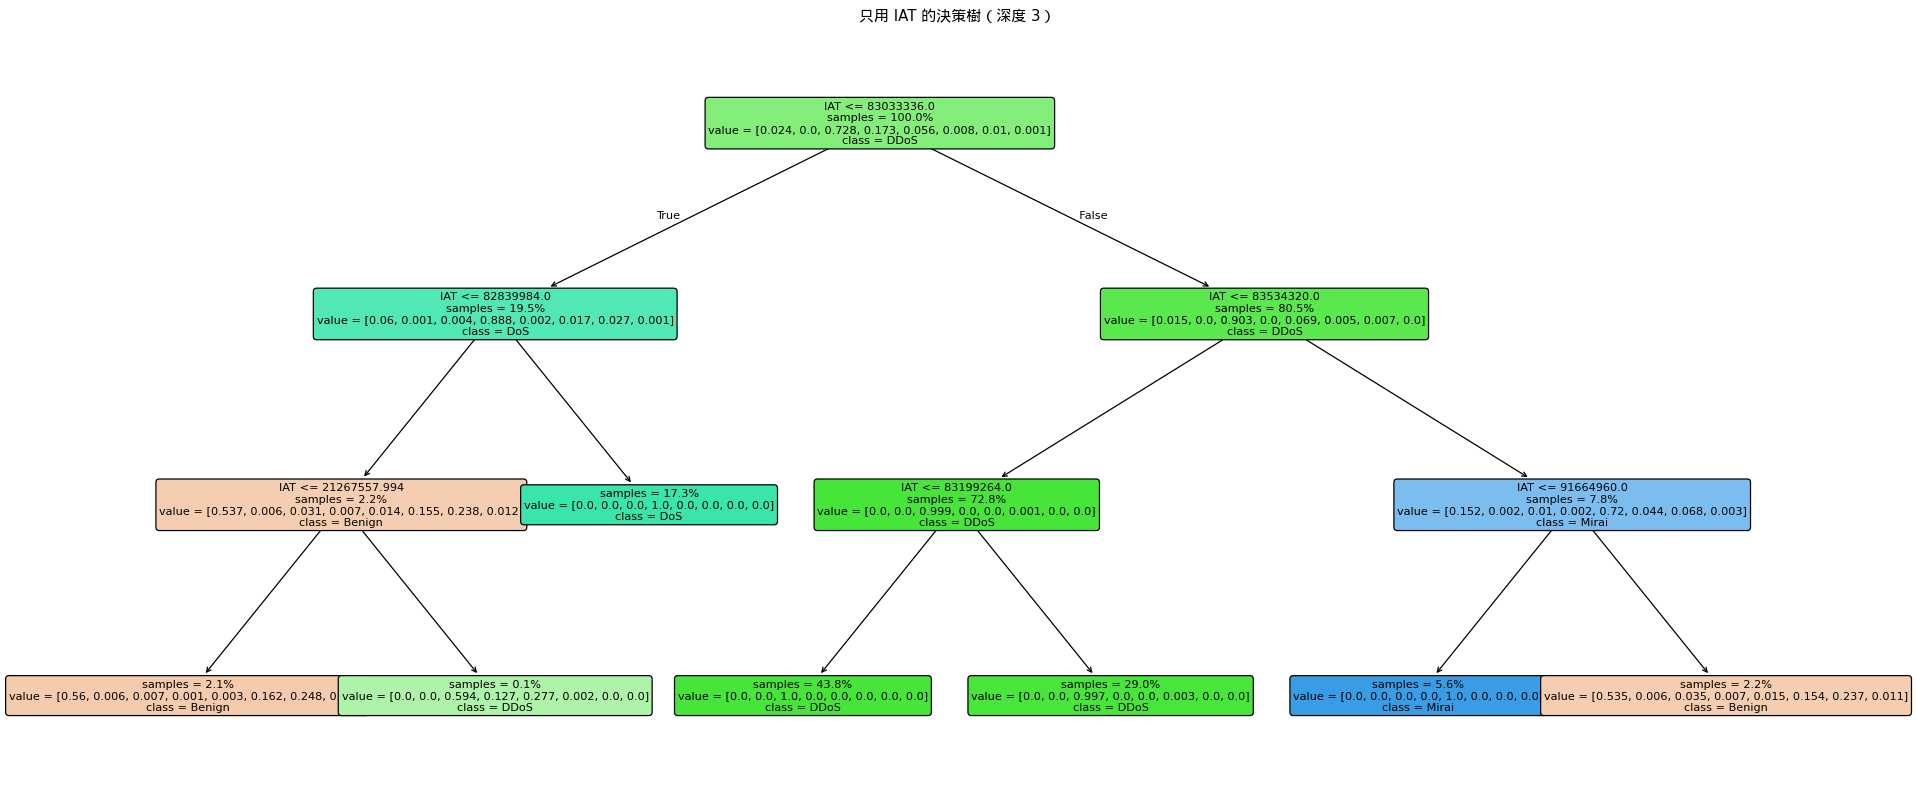

In [8]:
tree_ = best.tree_
print("分裂節點（IAT 門檻）：")
for node in range(tree_.node_count):
    if tree_.children_left[node] != tree_.children_right[node]:
        thr = tree_.threshold[node]
        print(f"  節點 {node:2d}: IAT <= {thr:.6g}   （= {thr / IAT_MAX:.4f} × max）  樣本數 {tree_.n_node_samples[node]:,}")

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(best, feature_names=["IAT"], class_names=list(best.classes_), filled=True,
          impurity=False, proportion=True, rounded=True, precision=3, fontsize=9, ax=ax)
ax.set_title("只用 IAT 的決策樹（深度 3）")
plt.tight_layout()
plt.show()

## 7. 在同一份資料切分下與 46 特徵隨機森林比較

第 3 節用的是完整資料（DDoS 佔 72.8%），accuracy 容易被多數類別撐高，也不能直接和其他實驗的數字比較。
這裡改用類別較平衡的抽樣資料，**所有模型用同一份訓練集與測試集**：

- 每個類別最多抽 60,000 列
- 75% 訓練 / 25% 測試，分層抽樣
- 隨機森林 60 棵樹

比較對象：
1. 永遠猜多數類的基準
2. 只用 IAT 的決策樹（深度 3）
3. 46 特徵隨機森林（原本的特徵集）
4. 45 特徵隨機森林（拿掉 IAT）

> 這一節需要讀取全部 47 欄並訓練兩個隨機森林，約需數分鐘。

抽樣後: 280,446 列，特徵 46 個（讀取與抽樣 7.5s）
y
DDoS           60000
DoS            60000
Mirai          60000
Benign         55859
Spoofing       24760
Recon          17985
Web-based       1186
Brute Force      656

                   訓練 accuracy  測試 accuracy  測試 balanced acc  測試 macro-F1   訓練秒數
模型                                                                              
基準：永遠猜多數類               0.2139       0.2139           0.1250       0.0441 0.1796
只用 IAT，決策樹深度 3          0.8442       0.8441           0.5112       0.4897 0.4183
46 特徵隨機森林               1.0000       0.9646           0.7690       0.8071 3.9027
45 特徵隨機森林（拿掉 IAT）       0.9989       0.8645           0.6556       0.6823 4.5151


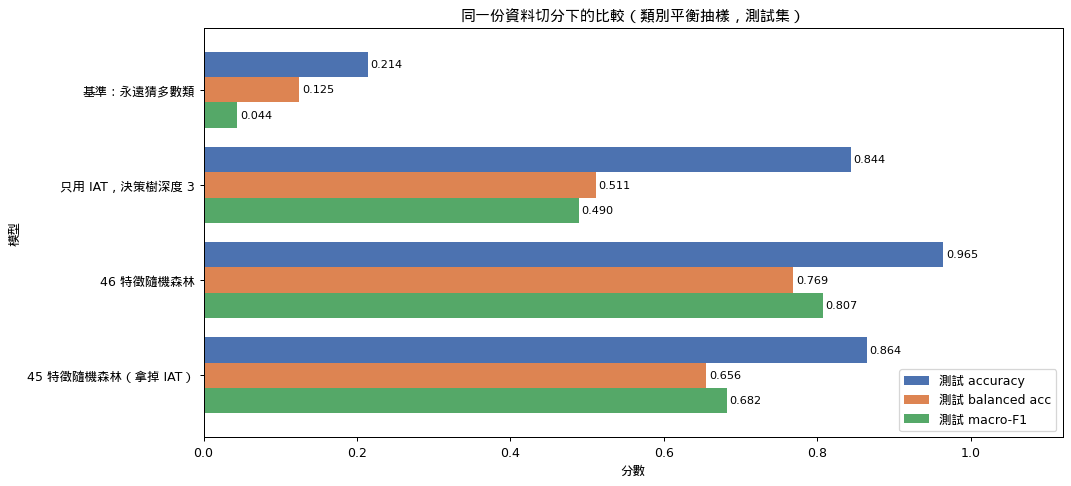

In [9]:
t0 = time.time()
full = pd.concat([pd.read_csv(f) for f in DATA_FILES], ignore_index=True)
full["y"] = full["label"].map(to_group)
full = full.drop(columns=["label"])
sampled = pd.concat([g.sample(min(len(g), 60000), random_state=RANDOM_STATE)
                     for _, g in full.groupby("y")], ignore_index=True)
del full
FEATURES = [c for c in sampled.columns if c != "y"]
print(f"抽樣後: {len(sampled):,} 列，特徵 {len(FEATURES)} 個（讀取與抽樣 {time.time() - t0:.1f}s）")
print(sampled["y"].value_counts().to_string())

Xs, ys = sampled[FEATURES], sampled["y"]
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.25, random_state=RANDOM_STATE, stratify=ys)

compare_rows = [
    evaluate("基準：永遠猜多數類", DummyClassifier(strategy="most_frequent"),
             Xs_tr, Xs_te, ys_tr, ys_te),
    evaluate("只用 IAT，決策樹深度 3", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
             Xs_tr[["IAT"]], Xs_te[["IAT"]], ys_tr, ys_te),
    evaluate("46 特徵隨機森林", RandomForestClassifier(n_estimators=60, n_jobs=-1, random_state=RANDOM_STATE),
             Xs_tr, Xs_te, ys_tr, ys_te),
    evaluate("45 特徵隨機森林（拿掉 IAT）",
             RandomForestClassifier(n_estimators=60, n_jobs=-1, random_state=RANDOM_STATE),
             Xs_tr.drop(columns=["IAT"]), Xs_te.drop(columns=["IAT"]), ys_tr, ys_te),
]
compare = pd.DataFrame(compare_rows).set_index("模型")
print()
print(compare.to_string(float_format=lambda v: f"{v:.4f}"))

ax = compare[metrics].plot.barh(figsize=(12, 5.5), width=0.8,
                                color=["#4C72B0", "#DD8452", "#55A868"])
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)
ax.set_xlim(0, 1.12)
ax.invert_yaxis()
ax.set_xlabel("分數")
ax.set_title("同一份資料切分下的比較（類別平衡抽樣，測試集）")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()